In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np

/tmp/ipykernel_2768862/2090009632.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [91]:
named = {
    "rtasipp": "RTAS",
    "plrtosipp": "MaxATFS",
    "hybrid": "MedATFS",
    "plrtosipphonly": "Baseline"
}

colord = {
    "plrtosipphonly": "k",
    "rtasipp": "b",
    "hybrid": "r",
    "plrtosipp": "g"
    
    
}
plt.rcParams.update({'font.size': 16})

ValueError: too many values to unpack (expected 3)

In [97]:
def plot_figure(folder, pattern, name, upper):
    dat = []
    for file_name in glob(folder + pattern):
        fn = file_name.replace(folder,"")
        try:
            #print(fn.replace(".out", "").split("_"))
            map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
        except:
            continue
        lookahead = int(lookahead)
        cost = float("inf")
        expansions = float("inf")
        with open(file_name) as f:
            for line in f.readlines():
                if "Arrival time:" in line:
                    cost = float(line.split(": ")[1])
                if "Nodes expanded:" in line:
                    expansions = int(line.split("Nodes expanded: ")[1].split()[0])
        dat.append((map, alg, lookahead, rep, expansions, cost))
    data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead","rep", "expansions", "cost"])
    plt.figure()
    for alg in colord:
        d = data.loc[data.Algorithm == alg]
        d = d.sort_values("Lookahead")
        x = []
        y = []
        yerr = []
        for lookahead in set(d.Lookahead):
            if (lookahead < 4) or (lookahead > upper):
               continue
            #if (d.loc[d.Lookahead== lookahead].cost < 10000).all():
            x.append(lookahead)
            y.append(d.loc[(d.Lookahead== lookahead)].cost.mean())
            yerr.append(np.quantile(d.loc[d.Lookahead == lookahead].cost, [0.5, 0.25, .5, .75, .9]))
        x = np.asarray(x)
        y = np.asarray(y)
        yerr = np.asarray(yerr).T
        ind = np.argsort(x)
        x = x[ind]
        y = y[ind]
        yerr = yerr[:,ind]
        plt.plot(x, yerr[2], color = colord[alg])
        plt.fill_between(x, yerr[1] , yerr[2], label = named[alg], alpha = .35 , color = colord[alg])
        plt.fill_between(x, yerr[2] , yerr[3], alpha = .25 , color = colord[alg])
    plt.ylim((100, 10000))
    plt.legend()
    plt.loglog()
    plt.ylabel("Goal Achievment Time")
    plt.xlabel("Search Budget (Expansions)")
    plt.tight_layout()
    plt.savefig(name)


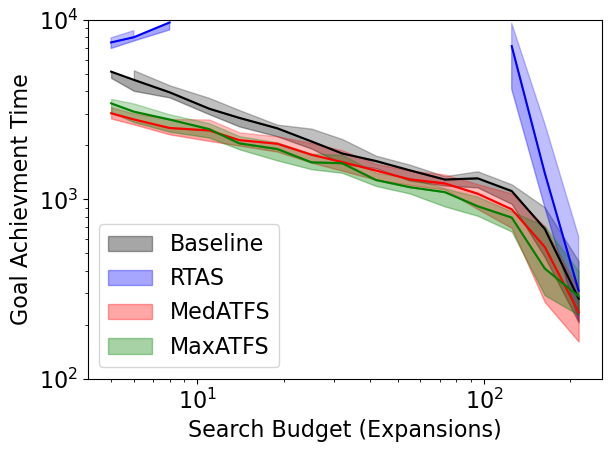

In [98]:
plot_figure("../results_overnight/", "*cup*", "cup_prelim.png", 256)

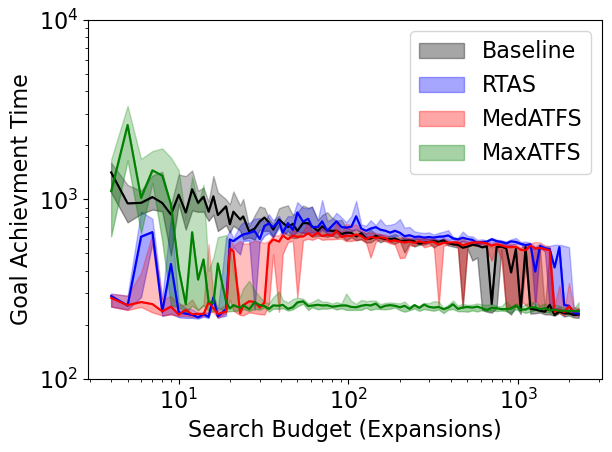

In [99]:
plot_figure("../results_overnight2/", "*warehouse*", "warehouse_prelim.png", 2400)

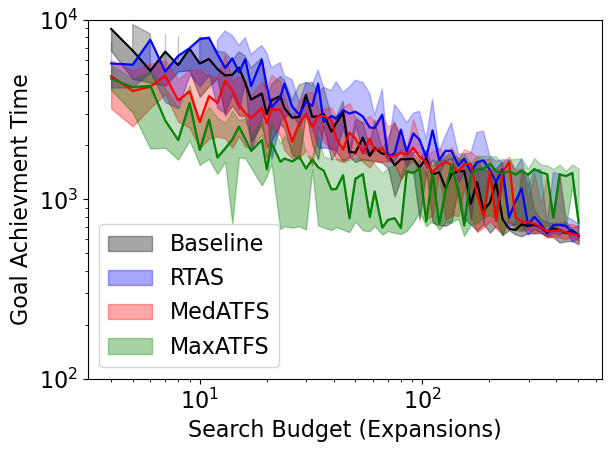

In [100]:
plot_figure("../results_overnight2/", "*den520d*", "den520d_prelim.png", 512)

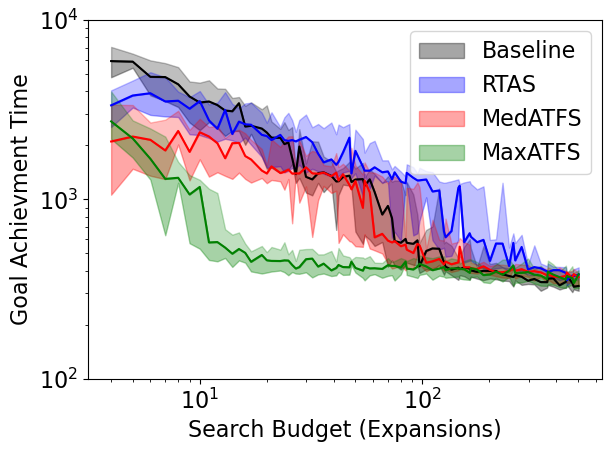

In [101]:
plot_figure("../results_sat2/", "*random*", "random_prelim.png", 512)